# Prediction workflow example

This notebook walks through the process of predicting fibroglandular tissue and blood vessel segments.

Set `INPUT_FILENAME` to the path of an MRI image file (suffix is probably `.nii.gz`).

In [1]:
INPUT_FILENAME = "MAMA-MIA-syn60868042/images/DUKE_001/DUKE_001_0001.nii.gz"
INPUT_FILENAME = "/net/projects2/vanguard/MAMA-MIA-syn60868042/images/DUKE_001/DUKE_001_0001.nii.gz"

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

from preprocessing import normalize_image, zscore_image

In [3]:
os.makedirs("STEP-1", exist_ok=True)
os.makedirs("STEP-2", exist_ok=True)
os.makedirs("STEP-3", exist_ok=True)

In [4]:
assert not (os.listdir("STEP-1") or os.listdir("STEP-2") or os.listdir("STEP-3")), "make sure the directories are empty"

AssertionError: make sure the directories are empty

## Pre-processing

In order to use the `predict.py` script, the image must be
* a NumPy array (file suffix `.npy`)
* rotated from $z$, $x$, $y$ to $x$, $y$, $z$
* scaled such that the mean pixel value is 0 and the standard deviation is 1.

Here's what the original array looks like:

In [5]:
original_array = sitk.GetArrayFromImage(sitk.ReadImage(INPUT_FILENAME))

In [6]:
original_array.shape

(160, 448, 448)

In [7]:
np.min(original_array), np.max(original_array), np.mean(original_array), np.std(original_array)

(np.int16(0),
 np.int16(554),
 np.float64(26.94983791429169),
 np.float64(31.12284366496779))

This plots a cross-section at $z=80$, which is the first dimension in this raw image.

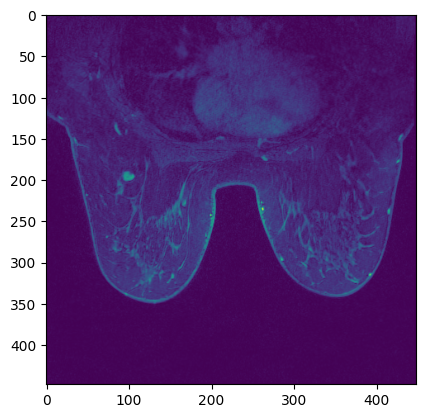

In [8]:
fig, ax = plt.subplots()

ax.imshow(original_array[80])

None

Here's a preprocessed array:

In [9]:
preprocessed_array = zscore_image(normalize_image(
    np.swapaxes(np.swapaxes(original_array, 0, 2), 0, 1)[::-1]
))

In [10]:
preprocessed_array.shape

(448, 448, 160)

In [11]:
np.min(preprocessed_array), np.max(preprocessed_array), np.mean(preprocessed_array), np.std(preprocessed_array)

(np.float64(-0.8710341507714101),
 np.float64(6.538330796390515),
 np.float64(2.9001744316738786e-17),
 np.float64(1.0))

This plots the cross-section at $z=80$, but notice that it is now the last dimension.

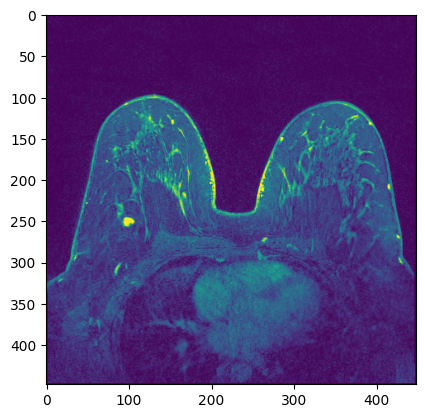

In [12]:
fig, ax = plt.subplots()

ax.imshow(preprocessed_array[:, :, 80])

None

Let's save it as `STEP-1` to use it in `predict.py`.

In [13]:
np.save("STEP-1/sample.npy", preprocessed_array)

## Predicting the breast mask

We will use `predict.py` twice on each image. The first time, it is used to draw a mask over the appropriate part of the image for the detailed analysis. This step is much faster than the one that finds fibroglandular tissue and blood vessels.

This script can be run in the terminal and it generates masks for _all_ of the images in its input directory. (Our `STEP-1` has only one image in it.)

The `trained_models/breast_model.pth` file contains the neural network that performs image segmentation.

In [14]:
!python predict.py --target-tissue breast --image STEP-1 --save-masks-dir STEP-2 --model-save-path trained_models/breast_model.pth

Loading in MRI volumes and mask volumes...
Loaded in 1 MRI volumes and mask volumes
/home/jmcarias/micromamba/envs/vanguard/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Predicting Masks...
  0%|                                                     | 0/1 [00:00<?, ?it/s]/home/jmcarias/micromamba/envs/vanguard/lib/python3.13/site-packages/torchio/transforms/transform.py:158: RuntimeWarning: Output shape (447, 447, 160) != target shape (np.int64(448), np.int64(448), np.int64(160)). Fixing with CropOrPad
  transformed = self.apply_transform(subject)
100%|█████████████████████████████████████████████

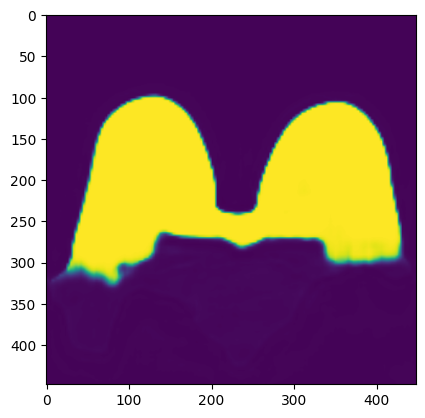

In [15]:
fig, ax = plt.subplots()

ax.imshow(np.load("STEP-2/sample.npy")[:, :, 80])

None

## Predicting fibroglandular tissue and blood vessels

This is the more time-consuming task: finding tissues within the breast, using the normalized image from `STEP-1` and the mask generated by `STEP-2`.

In [16]:
!python predict.py --target-tissue dv --image STEP-1 --input-mask STEP-2 --save-masks-dir STEP-3 --model-save-path trained_models/dv_model.pth

Loading in MRI volumes and mask volumes...
Loaded in 1 MRI volumes and mask volumes
with a total of 192 subvolumes across all volumes
/home/jmcarias/micromamba/envs/vanguard/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Predicting Masks...
100%|█████████████████████████████████████████| 192/192 [04:18<00:00,  1.35s/it]


In [17]:
final_image = np.load("STEP-3/sample.npy")

The `final_image` has three channels (first dimension), which are probabilities that a given pixel is fibroglandular tissue, blood vessel, or neither.

In [18]:
final_image.shape

(3, 448, 448, 160)

The minimum probability is 0 and the maximum is 1.

In [19]:
np.min(final_image), np.max(final_image)

(np.float16(0.0), np.float16(1.0))

The sum across the three channels is approximately equal to 1 (within numerical precision).

In [20]:
np.isclose(np.sum(final_image, axis=0), 1, rtol=0.002).all()

np.True_

To draw an image in which the color of each pixel is the most likely category, compute `np.argmax(final_image, axis=0)`.

To overlay it on the original `preprocessed_array`, call `ax.imshow` twice, with `alpha=0.5` on the overlay image.

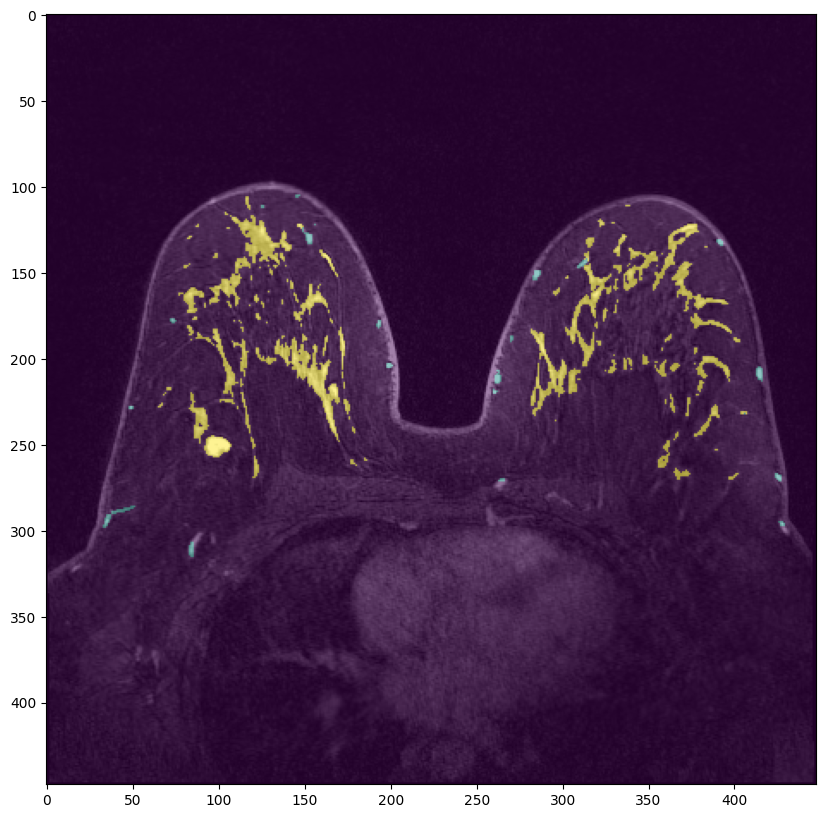

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(preprocessed_array[:, :, 80], cmap="gray")
ax.imshow(np.argmax(final_image, axis=0)[:, :, 80], alpha=0.5)

None

## Visualizing blood vessel segmentations in 3D

PyVista is a library for 3D visualization. It requires a lot of helper libraries to be installed with it (which is why I didn't try to import it at the top of this notebook—you might not have those libraries installed).

In [22]:
import pyvista as pv

Channel 1 is the blood vessels; viewing this component alone makes a 3D model in which color intensity is proportional to probability that a voxel is in a blood vessel.

Uncomment the `grid.plot` line to interactively rotate the image.

In [23]:
grid = pv.wrap(final_image[1].astype(float))
# grid.plot(volume=True, cmap="Blues")

The code below saves a rotating image as a short movie. Remember to set the movie's filename to properly represent `INPUT_FILENAME`.

In [24]:
plotter = pv.Plotter(off_screen=True)
plotter.add_volume(grid, opacity="linear", cmap="Blues")
plotter.open_movie("DUKE_001_0001.mp4")
n_frames = 60
for i in range(n_frames):
    plotter.camera_position = "yz"
    plotter.camera.elevation = 30
    plotter.camera.azimuth = 180 + i * 360 / n_frames
    plotter.render()
    plotter.write_frame()

plotter.close()

2025-10-10 14:36:25.097 (  13.373s) [    7F03EF48D440]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
